In [1]:
import pandas as pd

In [49]:
df = pd.read_csv(r"D:\BURHAN\DATA ANALIS\ALEX THE ANALYST\DATASET\Dataset 2\index.csv")
df

,Year,Month,Day,Federal Funds Target Rate,Federal Funds Upper Target,Federal Funds Lower Target,Effective Federal Funds Rate,Real GDP (Percent Change),Unemployment Rate,Inflation Rate
0,1954,7,1,NaN,NaN,NaN,0.80,4.6,5.8,NaN
1,1954,8,1,NaN,NaN,NaN,1.22,NaN,6.0,NaN
2,1954,9,1,NaN,NaN,NaN,1.06,NaN,6.1,NaN
3,1954,10,1,NaN,NaN,NaN,0.85,8.0,5.7,NaN
4,1954,11,1,NaN,NaN,NaN,0.83,NaN,5.3,NaN
...,...,...,...,...,...,...,...,...,...,...
899,2016,12,14,NaN,0.75,0.50,NaN,NaN,NaN,NaN
900,2017,1,1,NaN,0.75,0.50,0.65,NaN,4.8,2.3
901,2017,2,1,NaN,0.75,0.50,0.66,NaN,4.7,2.2
902,2017,3,1,NaN,0.75,0.50,NaN,NaN,NaN,NaN


In [50]:
df['Date'] = pd.to_datetime(df[['Year', 'Month', 'Day']])
df

,Year,Month,Day,Federal Funds Target Rate,Federal Funds Upper Target,Federal Funds Lower Target,Effective Federal Funds Rate,Real GDP (Percent Change),Unemployment Rate,Inflation Rate,Date
0,1954,7,1,NaN,NaN,NaN,0.80,4.6,5.8,NaN,1954-07-01
1,1954,8,1,NaN,NaN,NaN,1.22,NaN,6.0,NaN,1954-08-01
2,1954,9,1,NaN,NaN,NaN,1.06,NaN,6.1,NaN,1954-09-01
3,1954,10,1,NaN,NaN,NaN,0.85,8.0,5.7,NaN,1954-10-01
4,1954,11,1,NaN,NaN,NaN,0.83,NaN,5.3,NaN,1954-11-01
...,...,...,...,...,...,...,...,...,...,...,...
899,2016,12,14,NaN,0.75,0.50,NaN,NaN,NaN,NaN,2016-12-14
900,2017,1,1,NaN,0.75,0.50,0.65,NaN,4.8,2.3,2017-01-01
901,2017,2,1,NaN,0.75,0.50,0.66,NaN,4.7,2.2,2017-02-01
902,2017,3,1,NaN,0.75,0.50,NaN,NaN,NaN,NaN,2017-03-01


In [51]:
df = df.drop(columns=['Year','Month','Day'])
df

,Federal Funds Target Rate,Federal Funds Upper Target,Federal Funds Lower Target,Effective Federal Funds Rate,Real GDP (Percent Change),Unemployment Rate,Inflation Rate,Date
0,NaN,NaN,NaN,0.80,4.6,5.8,NaN,1954-07-01
1,NaN,NaN,NaN,1.22,NaN,6.0,NaN,1954-08-01
2,NaN,NaN,NaN,1.06,NaN,6.1,NaN,1954-09-01
3,NaN,NaN,NaN,0.85,8.0,5.7,NaN,1954-10-01
4,NaN,NaN,NaN,0.83,NaN,5.3,NaN,1954-11-01
...,...,...,...,...,...,...,...,...
899,NaN,0.75,0.50,NaN,NaN,NaN,NaN,2016-12-14
900,NaN,0.75,0.50,0.65,NaN,4.8,2.3,2017-01-01
901,NaN,0.75,0.50,0.66,NaN,4.7,2.2,2017-02-01
902,NaN,0.75,0.50,NaN,NaN,NaN,NaN,2017-03-01


In [52]:
df.set_index('Date', inplace=True)                # 1. Menjadikan kolom 'Date' sebagai Index utama tabel

In [53]:
df_cleaned = df.ffill()                     # 2. Mengisi data yang kosong dengan nilai terakhir yang valid (Forward Fill)

In [54]:
print(df_cleaned.info())                    # 3. Mari kita cek kembali apakah masih ada data yang kosong!

<class 'pandas.DataFrame'>
DatetimeIndex: 904 entries, 1954-07-01 to 2017-03-16
Data columns (total 7 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Federal Funds Target Rate     565 non-null    float64
 1   Federal Funds Upper Target    103 non-null    float64
 2   Federal Funds Lower Target    103 non-null    float64
 3   Effective Federal Funds Rate  904 non-null    float64
 4   Real GDP (Percent Change)     904 non-null    float64
 5   Unemployment Rate             904 non-null    float64
 6   Inflation Rate                862 non-null    float64
dtypes: float64(7)
memory usage: 56.5 KB
None


In [56]:
import matplotlib.pyplot as plt

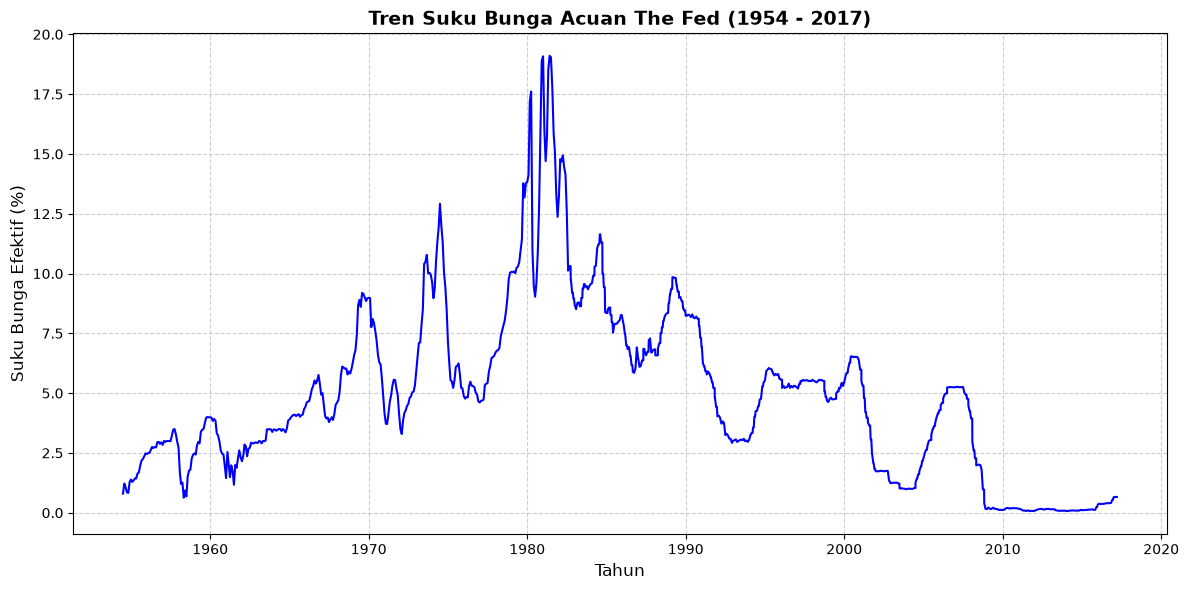

In [57]:
# 1. Mengatur ukuran kanvas grafik agar lebar dan jelas
plt.figure(figsize=(12, 6))

# 2. Membuat grafik garis (Sumbu X = Index/Waktu, Sumbu Y = Suku Bunga)
plt.plot(df_cleaned.index, df_cleaned['Effective Federal Funds Rate'], color='blue', linewidth=1.5)

# 3. Menambahkan Judul dan Label agar informatif
plt.title('Tren Suku Bunga Acuan The Fed (1954 - 2017)', fontsize=14, fontweight='bold')
plt.xlabel('Tahun', fontsize=12)
plt.ylabel('Suku Bunga Efektif (%)', fontsize=12)

# 4. Menambahkan garis bantu (grid) dan merapikan layout
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# Lanjut membuat Dual Y-Axis Line Chart (Visualisasi Bivariat)

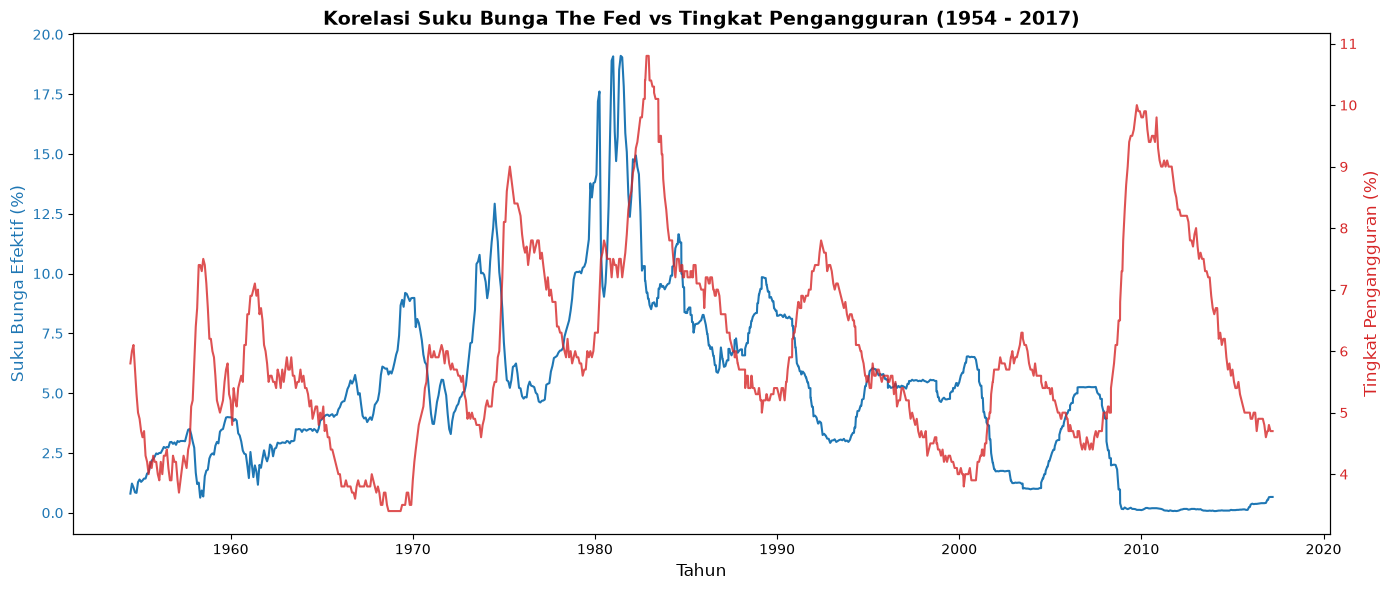

In [58]:
# 1. Menyiapkan Kanvas
fig, ax1 = plt.subplots(figsize=(14, 6))

# 2. Menggambar Garis Pertama (Suku Bunga) di Sumbu Y Kiri (ax1)
color1 = 'tab:blue'
ax1.set_xlabel('Tahun', fontsize=12)
ax1.set_ylabel('Suku Bunga Efektif (%)', color=color1, fontsize=12)
ax1.plot(df_cleaned.index, df_cleaned['Effective Federal Funds Rate'], color=color1, linewidth=1.5, label='Suku Bunga')
ax1.tick_params(axis='y', labelcolor=color1)

# 3. Membuat Sumbu Y Kedua (ax2) yang berbagi sumbu X yang sama
ax2 = ax1.twinx()

# 4. Menggambar Garis Kedua (Pengangguran) di Sumbu Y Kanan (ax2)
color2 = 'tab:red'
ax2.set_ylabel('Tingkat Pengangguran (%)', color=color2, fontsize=12)
ax2.plot(df_cleaned.index, df_cleaned['Unemployment Rate'], color=color2, linewidth=1.5, label='Pengangguran', alpha=0.8)
ax2.tick_params(axis='y', labelcolor=color2)

# 5. Merapikan Layout dan Judul
plt.title('Korelasi Suku Bunga The Fed vs Tingkat Pengangguran (1954 - 2017)', fontsize=14, fontweight='bold')
fig.tight_layout()
plt.show()

In [59]:
df_cleaned[['Effective Federal Funds Rate', 'Unemployment Rate']].corr()                # Menghitung Korelasi

,Effective Federal Funds Rate,Unemployment Rate
Effective Federal Funds Rate,1.000000,0.097814
Unemployment Rate,0.097814,1.000000


In [61]:
# Menyimpan dataframe yang sudah bersih ke file CSV baru
df_cleaned.to_csv('cleaned_macroeconomic_data.csv')

In [62]:
import os

In [63]:
# 1. Mengecek lokasi folder tempat Anda bekerja saat ini
lokasi_folder = os.getcwd()
print("Saya sedang bekerja di folder:", lokasi_folder)

Saya sedang bekerja di folder: C:\Users\advan
